![图片描述](GAN_02.png)

### 1. What exactly is a GAN?

There are two neural networks inside a GAN:

* **Generator (G)**
    * **Input:** Random noise `z`
    * **Output:** Generated fake sample `G(z)`
* **Discriminator (D)**
    * **Input:** A sample `x`
    * **Output:** The probability that this sample is real `D(x)`

**They compete against each other:**
* **The Discriminator tries to distinguish between:**
    * Real samples: $x \sim p_{data}$
    * Generated samples: $G(z)$
* **The Generator tries to fool the Discriminator:**
    * By making $D(G(z))$ as close to **1** as possible.

### 2. Overall Workflow of GAN

GAN training usually involves cycling through these steps:

**Step 1: Take a batch of real data**

**Step 2: Generate a batch of fake data**

**Step 3: Train the Discriminator (D)**

**Step 4: Train the Generator (G)**

### Discriminator

**Forward:**
$$A_D = W_D X + b_D$$
$$\hat{Y} = \sigma(A_D)$$

**Loss:**
$$L_D = -\frac{1}{m} \sum [Y \log \hat{Y} + (1 - Y) \log (1 - \hat{Y})]$$

Where:
* **$Y$**: The real label. Real samples are **1**, fake samples are **0**.
* **$\hat{Y}$**: The probability predicted by the model.

**Backward:**
$$dA_D = \hat{Y} - Y$$
$$dW_D = \frac{1}{m} dA_D X^T$$
$$db_D = \frac{1}{m} \sum dA_D$$

### Generator

**Forward:**
$$A_G = W_G Z + b_G$$
$$X_{fake} = \tanh(A_G)$$

**Generator Loss:**
$$L_G = -\frac{1}{m} \sum \log D(G(Z))$$

**Backward:**
$$dA_D = D(G(Z)) - 1$$
$$dX_{fake} = W_D^T dA_D$$
$$dA_G = dX_{fake} \odot (1 - X_{fake}^2)$$
$$dW_G = \frac{1}{m} dA_G Z^T$$
$$db_G = \frac{1}{m} \sum dA_G$$

In [32]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

### Activation functions

In [33]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def tanh(x):
    return np.tanh(x)

def tanh_grad_from_output(y):
    # 如果 y = tanh(x)，则 dy/dx = 1 - y^2
    return 1.0 - y**2

In [34]:
def sample_real(batch_size):
    return np.random.normal(loc=2.0, scale=0.2, size=(1, batch_size))

def sample_noise(batch_size, z_dim=3):
    return np.random.normal(0.0, 1.0, size=(z_dim, batch_size))

In [35]:
def init_params(z_dim=3, g_hidden=8, x_dim=1, d_hidden=8):
    params = {}

    # Generator
    params["Wg1"] = np.random.randn(g_hidden, z_dim) * 0.1
    params["bg1"] = np.zeros((g_hidden, 1))

    params["Wg2"] = np.random.randn(x_dim, g_hidden) * 0.1
    params["bg2"] = np.zeros((x_dim, 1))

    # Discriminator
    params["Wd1"] = np.random.randn(d_hidden, x_dim) * 0.1
    params["bd1"] = np.zeros((d_hidden, 1))

    params["Wd2"] = np.random.randn(1, d_hidden) * 0.1
    params["bd2"] = np.zeros((1, 1))

    return params

**Forward:**
$$A_G = W_G Z + b_G$$
$$X_{fake} = \tanh(A_G)$$

In [36]:
def generator_forward(Z, params):
    Wg1, bg1 = params["Wg1"], params["bg1"]
    Wg2, bg2 = params["Wg2"], params["bg2"]

    Ag1 = Wg1 @ Z + bg1
    Hg = relu(Ag1)

    Ag2 = Wg2 @ Hg + bg2
    X_fake = tanh(Ag2)

    cache = {
        "Z": Z,
        "Ag1": Ag1,
        "Hg": Hg,
        "Ag2": Ag2,
        "X_fake": X_fake
    }
    return X_fake, cache

**Forward:**
$$A_D = W_D X + b_D$$
$$\hat{Y} = \sigma(A_D)$$

In [37]:
def discriminator_forward(X, params):
    Wd1, bd1 = params["Wd1"], params["bd1"]
    Wd2, bd2 = params["Wd2"], params["bd2"]

    Ad1 = Wd1 @ X + bd1
    Hd = relu(Ad1)

    Ad2 = Wd2 @ Hd + bd2
    Y_hat = sigmoid(Ad2)

    cache = {
        "X": X,
        "Ad1": Ad1,
        "Hd": Hd,
        "Ad2": Ad2,
        "Y_hat": Y_hat
    }
    return Y_hat, cache

**Discriminator Loss:**
$$L_D = -\frac{1}{m} \sum [Y \log \hat{Y} + (1 - Y) \log (1 - \hat{Y})]$$
**Generator Loss:**
$$L_G = -\frac{1}{m} \sum \log D(G(Z))$$

In [38]:
def discriminator_loss(Y_real_hat, Y_fake_hat, eps=1e-8):
    loss_real = -np.mean(np.log(Y_real_hat + eps))
    loss_fake = -np.mean(np.log(1 - Y_fake_hat + eps))
    return loss_real + loss_fake

def generator_loss(Y_fake_hat, eps=1e-8):
    return -np.mean(np.log(Y_fake_hat + eps))

In [39]:
def discriminator_backward(X_real, X_fake, params):
    m = X_real.shape[1]

    # forward real
    Y_real_hat, cache_real = discriminator_forward(X_real, params)

    # forward fake
    Y_fake_hat, cache_fake = discriminator_forward(X_fake, params)

    # labels
    Y_real = np.ones((1, m))
    Y_fake = np.zeros((1, m))

    # loss
    loss_d = discriminator_loss(Y_real_hat, Y_fake_hat)

    # ===== real branch =====
    dAd2_real = Y_real_hat - Y_real
    dWd2_real = (dAd2_real @ cache_real["Hd"].T) / m
    dbd2_real = np.sum(dAd2_real, axis=1, keepdims=True) / m

    dHd_real = params["Wd2"].T @ dAd2_real
    dAd1_real = dHd_real * relu_grad(cache_real["Ad1"])
    dWd1_real = (dAd1_real @ cache_real["X"].T) / m
    dbd1_real = np.sum(dAd1_real, axis=1, keepdims=True) / m

    # ===== fake branch =====
    dAd2_fake = Y_fake_hat - Y_fake
    dWd2_fake = (dAd2_fake @ cache_fake["Hd"].T) / m
    dbd2_fake = np.sum(dAd2_fake, axis=1, keepdims=True) / m

    dHd_fake = params["Wd2"].T @ dAd2_fake
    dAd1_fake = dHd_fake * relu_grad(cache_fake["Ad1"])
    dWd1_fake = (dAd1_fake @ cache_fake["X"].T) / m
    dbd1_fake = np.sum(dAd1_fake, axis=1, keepdims=True) / m

    # total gradients
    grads = {}
    grads["Wd2"] = dWd2_real + dWd2_fake
    grads["bd2"] = dbd2_real + dbd2_fake
    grads["Wd1"] = dWd1_real + dWd1_fake
    grads["bd1"] = dbd1_real + dbd1_fake

    info = {
        "loss_d": loss_d,
        "Y_real_hat_mean": np.mean(Y_real_hat),
        "Y_fake_hat_mean": np.mean(Y_fake_hat)
    }

    return grads, info

In [40]:
def generator_backward(Z, params):
    m = Z.shape[1]

    # 1) forward through generator
    X_fake, g_cache = generator_forward(Z, params)

    # 2) forward through discriminator
    Y_fake_hat, d_cache = discriminator_forward(X_fake, params)

    # 3) loss
    loss_g = generator_loss(Y_fake_hat)

    # ------------------------------------------------
    # 对生成器来说，希望 fake 被判成 1
    # 所以在判别器输出层，相当于 target = 1
    # dAd2 = Y_hat - 1
    # ------------------------------------------------
    dAd2 = Y_fake_hat - 1.0

    # 4) 先通过判别器往回传，但不更新判别器参数
    dHd = params["Wd2"].T @ dAd2
    dAd1 = dHd * relu_grad(d_cache["Ad1"])
    dX_fake = params["Wd1"].T @ dAd1

    # 5) 回到生成器输出层 tanh
    dAg2 = dX_fake * tanh_grad_from_output(g_cache["X_fake"])
    dWg2 = (dAg2 @ g_cache["Hg"].T) / m
    dbg2 = np.sum(dAg2, axis=1, keepdims=True) / m

    # 6) 回到生成器隐藏层
    dHg = params["Wg2"].T @ dAg2
    dAg1 = dHg * relu_grad(g_cache["Ag1"])
    dWg1 = (dAg1 @ g_cache["Z"].T) / m
    dbg1 = np.sum(dAg1, axis=1, keepdims=True) / m

    grads = {}
    grads["Wg2"] = dWg2
    grads["bg2"] = dbg2
    grads["Wg1"] = dWg1
    grads["bg1"] = dbg1

    info = {
        "loss_g": loss_g,
        "Y_fake_hat_mean_for_g": np.mean(Y_fake_hat),
        "X_fake_mean": np.mean(X_fake)
    }

    return grads, info

In [41]:
def update_discriminator(params, grads, lr=0.01):
    params["Wd2"] -= lr * grads["Wd2"]
    params["bd2"] -= lr * grads["bd2"]
    params["Wd1"] -= lr * grads["Wd1"]
    params["bd1"] -= lr * grads["bd1"]

def update_generator(params, grads, lr=0.01):
    params["Wg2"] -= lr * grads["Wg2"]
    params["bg2"] -= lr * grads["bg2"]
    params["Wg1"] -= lr * grads["Wg1"]
    params["bg1"] -= lr * grads["bg1"]

In [42]:
# 超参数
z_dim = 3
g_hidden = 8
d_hidden = 8
batch_size = 64
epochs = 5000
lr_g = 0.01
lr_d = 0.01

params = init_params(z_dim=z_dim, g_hidden=g_hidden, x_dim=1, d_hidden=d_hidden)

loss_d_list = []
loss_g_list = []
real_score_list = []
fake_score_list = []

for epoch in range(epochs):
    # =========================
    # 1. 训练判别器
    # =========================
    X_real = sample_real(batch_size)
    Z = sample_noise(batch_size, z_dim=z_dim)
    X_fake, _ = generator_forward(Z, params)

    d_grads, d_info = discriminator_backward(X_real, X_fake, params)
    update_discriminator(params, d_grads, lr=lr_d)

    # =========================
    # 2. 训练生成器
    # =========================
    Z = sample_noise(batch_size, z_dim=z_dim)
    g_grads, g_info = generator_backward(Z, params)
    update_generator(params, g_grads, lr=lr_g)

    # record
    loss_d_list.append(d_info["loss_d"])
    loss_g_list.append(g_info["loss_g"])
    real_score_list.append(d_info["Y_real_hat_mean"])
    fake_score_list.append(d_info["Y_fake_hat_mean"])

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"D loss = {d_info['loss_d']:.4f} | "
            f"G loss = {g_info['loss_g']:.4f} | "
            f"D(real) = {d_info['Y_real_hat_mean']:.4f} | "
            f"D(fake) = {d_info['Y_fake_hat_mean']:.4f} | "
            f"G(x_fake) mean = {g_info['X_fake_mean']:.4f}"
        )

Epoch    0 | D loss = 1.3881 | G loss = 0.6933 | D(real) = 0.4990 | D(fake) = 0.4999 | G(x_fake) mean = -0.0094
Epoch  500 | D loss = 0.7533 | G loss = 0.9099 | D(real) = 0.7920 | D(fake) = 0.4043 | G(x_fake) mean = 0.8039
Epoch 1000 | D loss = 0.2988 | G loss = 1.6955 | D(real) = 0.9111 | D(fake) = 0.1844 | G(x_fake) mean = 0.9805
Epoch 1500 | D loss = 0.1530 | G loss = 2.3110 | D(real) = 0.9540 | D(fake) = 0.0991 | G(x_fake) mean = 0.9935
Epoch 2000 | D loss = 0.1102 | G loss = 2.8047 | D(real) = 0.9567 | D(fake) = 0.0604 | G(x_fake) mean = 0.9965
Epoch 2500 | D loss = 0.0651 | G loss = 3.1965 | D(real) = 0.9779 | D(fake) = 0.0410 | G(x_fake) mean = 0.9977
Epoch 3000 | D loss = 0.0565 | G loss = 3.4861 | D(real) = 0.9803 | D(fake) = 0.0306 | G(x_fake) mean = 0.9987
Epoch 3500 | D loss = 0.0341 | G loss = 3.7362 | D(real) = 0.9903 | D(fake) = 0.0239 | G(x_fake) mean = 0.9989
Epoch 4000 | D loss = 0.0376 | G loss = 3.9281 | D(real) = 0.9837 | D(fake) = 0.0196 | G(x_fake) mean = 0.9994


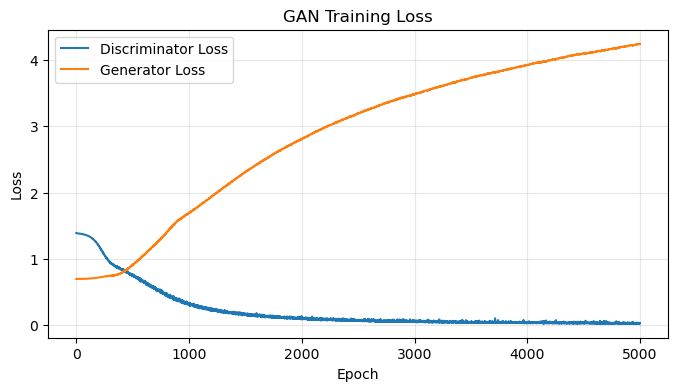

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(loss_d_list, label="Discriminator Loss")
plt.plot(loss_g_list, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()